In [30]:
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers

In [4]:
# load fasion mnist dataset
df=tf.keras.datasets.fashion_mnist.load_data()

In [11]:
# check the shape of data
print(df[0][0].shape)  #   train images shape
print(df[1][0].shape)  #   test images shape
print(df[0][1].shape) #    train  label shape
print(df[1][1].shape) #    test label shape

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [10]:
(train_images,train_labels),(test_images,test_labels)=df  # separate train and test data

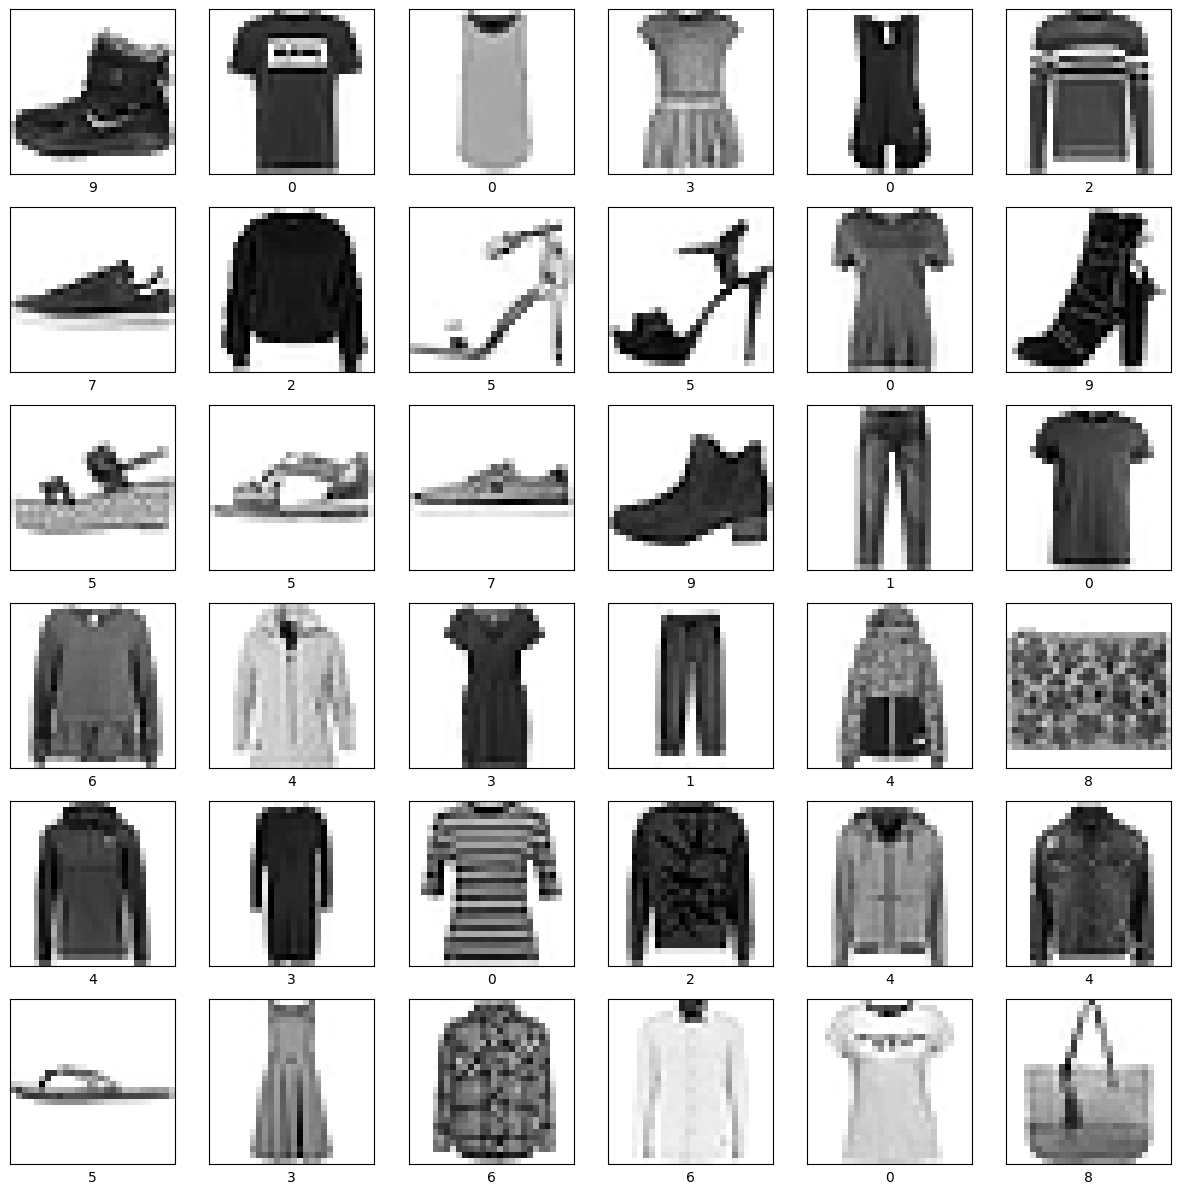

In [17]:
# Let' see some images 
plt.figure(figsize=(15,15))
for i in range(36):
    plt.subplot(6,6,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i],cmap=plt.cm.binary)
    plt.xlabel(train_labels[i])
    
plt.show()

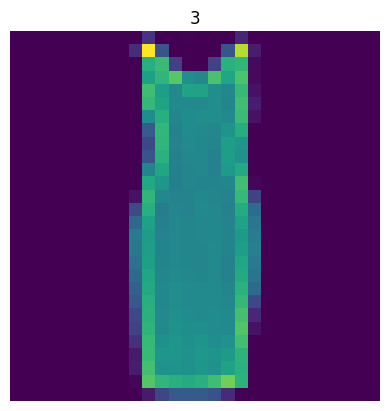

In [22]:
# see only one image 
plt.imshow(train_images[4999])
plt.title(train_labels[4999])
plt.axis('off')
plt.show()

In [27]:
# let's add class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


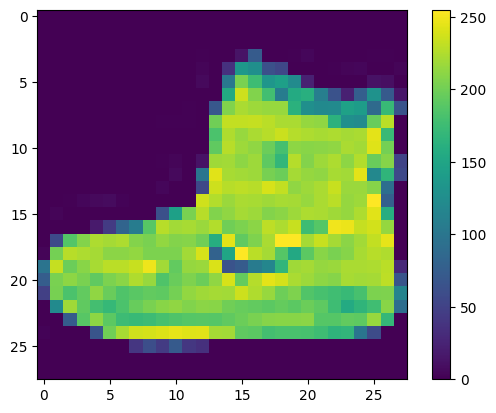

In [28]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [29]:
# Normalizing data 
train_images = train_images / 255.0
test_images = test_images / 255.0

# Build the model 

In [37]:
# Create input layer

input_layer=layers.Input(shape=(28,28,1))


# build the CNN MODEL

model = tf.keras.Sequential([input_layer,
                             layers.Conv2D(filters=32,kernel_size= (3, 3), activation='relu'),   # Convo layer
                            # #  layers.Conv2D(filters=10,kernel_size= (3, 3), activation='relu'),
                             layers.MaxPooling2D(pool_size=(3,3)),
                             layers.Conv2D(filters=64,kernel_size= (3, 3), activation='relu'),
                            #  layers.Conv2D(filters=10,kernel_size= (3, 3), activation='relu')
                             layers.MaxPooling2D(),
                             layers.Flatten(),
                             layers.Dense(10, activation='')   # output layer
                            ])

# compile the model

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,586 (96.04 KB)

 Trainable params: 24,586 (96.04 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Train the model

model.fit(train_images,train_labels,epochs=10,batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.7292 - loss: 0.7675
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8662 - loss: 0.3723
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.8858 - loss: 0.3209
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8933 - loss: 0.2895
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9046 - loss: 0.2643
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9068 - loss: 0.2555
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9119 - loss: 0.2439
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9162 - loss: 0.2297
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9200 - loss: 0.2166
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9247 - loss: 0.2092


In [39]:
# model evaluation

loss,accuracy=model.evaluate(test_images,test_labels,verbose=2)
print(f"Loss: {loss:.2f}")
print(f"Accuracy: {accuracy*100:.2f}")

313/313 - 2s - 5ms/step - accuracy: 0.9013 - loss: 0.2847
Loss: 0.28
Accuracy: 90.13


In [40]:
# Save the model

model.save('fashion_mnist.h5')

# Make predictions

In [42]:
test_images.shape

(10000, 28, 28)

In [43]:
  predictions=model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [49]:
predictions[0]   # in this the highest prob is our label

array([2.7729813e-08, 1.6506983e-12, 2.4851365e-10, 2.8025796e-10,
       5.4064603e-11, 2.5624040e-05, 8.6561673e-09, 1.7890285e-04,
       2.3286078e-05, 9.9977213e-01], dtype=float32)

In [50]:
test_labels[44]

6

In [51]:
np.argmax(predictions[44])  # This is easier

4

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


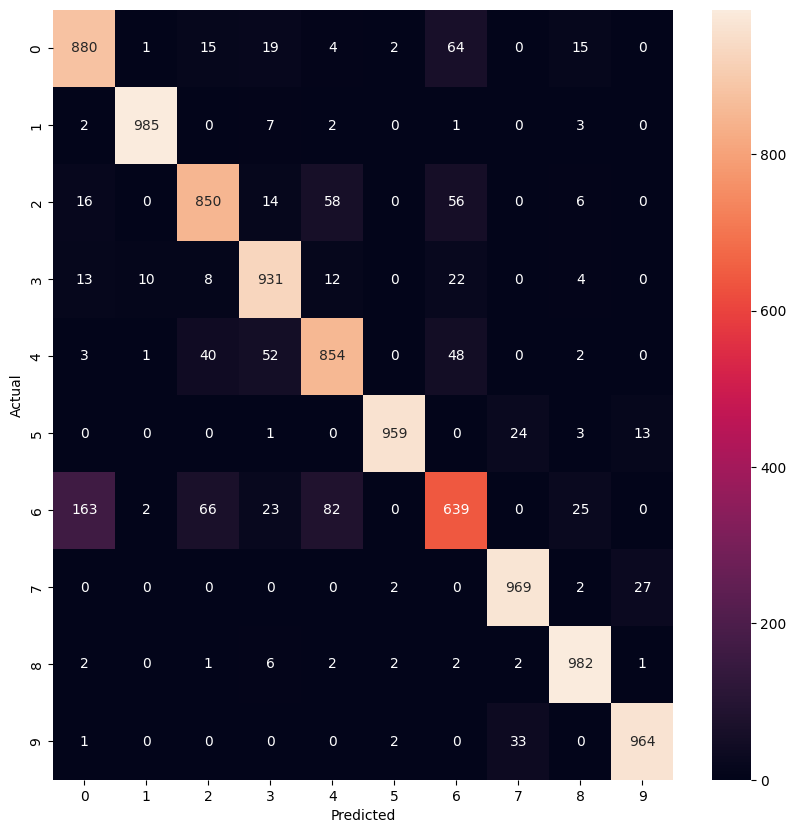

In [52]:
# draw a confusion matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_images)
y_pred = np.argmax(y_pred, axis=1)
cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()